<a href="https://colab.research.google.com/github/tsniang-cmkl/FTIR-Microplastics-Classification/blob/main/PatchTST_FTIR_Microplastics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 PatchTST — Classification de Microplastiques par Spectres FTIR
### CMKL University | Stage 2026

**Objectif** : Classifier des spectres FTIR de microplastiques dans l'eau  
**Modèle** : PatchTST (Nie et al., ICLR 2023)  
**Données** : 22 classes originales + 9 nouvelles classes = jusqu'à 31 types de MP

---
## Structure du notebook
1. Installation & imports
2. Connexion Google Drive
3. Exploration et chargement des données
4. Prétraitement des spectres
5. Dataset & DataLoader PyTorch
6. Modèle PatchTST
7. Entraînement
8. Évaluation & visualisation


## 1. Installation & Imports

In [ ]:
# Installation des librairies nécessaires
!pip install transformers -q
!pip install scikit-learn -q
!pip install seaborn -q

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Vérification GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Setup OK ✓')

Device : cpu
Setup OK ✓


## 2. Connexion Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ⚠️  MODIFIE CE CHEMIN selon l'emplacement exact de ton dossier sur Drive
DRIVE_ROOT = '/content/drive/MyDrive/Internship Datas/2026 - Complete FTIR Dataset'

# Chemins vers chaque sous-dossier
PATHS = {
    '2023_base'    : os.path.join(DRIVE_ROOT, 'Donnees_CSV_Propres_2023'),
    'membrane'     : os.path.join(DRIVE_ROOT, 'csv 2023 and 2025 Membrane Filter'),
    '2025_ext'     : os.path.join(DRIVE_ROOT, 'csv 2025 Dataset 1 - Same 22 MP Types - Add 40 Spectra'),
    '2025_new'     : os.path.join(DRIVE_ROOT, 'csv 2025 Dataset 2 - New 9 MP Types - 50 Clean and 100 Noisy'),
}

# Vérification que les dossiers existent
for name, path in PATHS.items():
    exists = os.path.exists(path)
    n_csv  = len(glob.glob(os.path.join(path, '**/*.csv'), recursive=True))
    print(f'  {name:15s} | {"✓" if exists else "✗ INTROUVABLE"} | {n_csv} fichiers CSV')

  2023_base       | ✓ | 211 fichiers CSV
  membrane        | ✓ | 6 fichiers CSV
  2025_ext        | ✓ | 23 fichiers CSV
  2025_new        | ✓ | 17 fichiers CSV


## 3. Exploration et chargement des données

### 3.1 Comprendre la structure de tes CSV
On regarde d'abord à quoi ressemble un fichier avant de tout charger.

In [ ]:
def explore_csv(path, n=3):
    """
    Affiche les premières lignes de n fichiers CSV
    pour comprendre leur structure (séparateur, colonnes, etc.)
    """
    files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)[:n]
    for f in files:
        print(f'\n📄 {os.path.basename(f)}')
        # Essayer différents séparateurs
        for sep in [',', ';', '\t', ' ']:
            try:
                df = pd.read_csv(f, sep=sep, nrows=3)
                if len(df.columns) >= 2:
                    print(f'  Séparateur : {repr(sep)}')
                    print(f'  Colonnes   : {list(df.columns)}')
                    print(f'  Shape      : {df.shape}')
                    print(df.head(3))
                    break
            except:
                continue

# Explorer le premier dossier pour comprendre la structure
explore_csv(PATHS['2025_ext'], n=2)


📄 Acrylic-add_40 spectrums.csv
  Séparateur : ';'
  Colonnes   : ['Unnamed: 0', 'Acrylic-add_40 spectrums.SPG', 'Unnamed: 2']
  Shape      : (3, 3)
           Unnamed: 0 Acrylic-add_40 spectrums.SPG  Unnamed: 2
0  Wavenumbers [1/cm]                   Absorbance         NaN
1            4000,122                  0,006291046         NaN
2            3999,640                  0,006279549         NaN

📄 Cellulose-add_40 spectrums.csv
  Séparateur : ';'
  Colonnes   : ['Unnamed: 0', 'Cellulose-add_40 spectrums.SPG', 'Unnamed: 2']
  Shape      : (3, 3)
           Unnamed: 0 Cellulose-add_40 spectrums.SPG  Unnamed: 2
0  Wavenumbers [1/cm]                     Absorbance         NaN
1            4000,122                    0,008198078         NaN
2            3999,640                    0,008178258         NaN


In [ ]:
# Configuration des dossiers
FOLDER_CONFIG = {
    '2023_base' : {'sep': ',', 'header': None,  'skiprows': 0},
    'membrane'  : {'sep': ';', 'header': None,  'skiprows': 2},
    '2025_ext'  : {'sep': ';', 'header': None,  'skiprows': 2},
    '2025_new'  : {'sep': ';', 'header': None,  'skiprows': 2},
}

WAVENUMBER_COL    = 0
ABSORBANCE_COL    = 1

def read_spectrum(filepath, sep=',', skiprows=0):
    """
    Lit un fichier CSV et retourne (wavenumbers, absorbances).
    Retourne (None, None) si le fichier est invalide pour éviter le crash d'unpacking.
    """
    try:
        df = pd.read_csv(
            filepath,
            sep=sep,
            header=None,
            skiprows=skiprows,
            low_memory=False,
            decimal=','
        )

        # Conversion forcée : transforme le texte récalcitrant en NaN, puis supprime la ligne
        wn_col = pd.to_numeric(df.iloc[:, WAVENUMBER_COL], errors='coerce')
        ab_col = pd.to_numeric(df.iloc[:, ABSORBANCE_COL], errors='coerce')
        clean_df = pd.DataFrame({'wn': wn_col, 'ab': ab_col}).dropna()

        wn = clean_df['wn'].values
        ab = clean_df['ab'].values

        # Trier par wavenumber croissant
        order = np.argsort(wn)
        return wn[order], ab[order]

    except Exception as e:
        print(f'  ✗ Erreur {os.path.basename(filepath)} : {e}')
        return None, None

# Test sur un fichier 2023 (en excluant explicitement le fichier système 'ref.csv')
test_files = [f for f in glob.glob(os.path.join(PATHS['2023_base'], '**/*.csv'), recursive=True) if 'ref.csv' not in f]

if test_files:
    # On récupère les paramètres du dictionnaire
    conf = FOLDER_CONFIG['2023_base']
    wn, ab = read_spectrum(test_files[0], sep=conf['sep'], skiprows=conf['skiprows'])

    if wn is not None:
        print(f'Fichier test : {os.path.basename(test_files[0])}')
        print(f'  Plage wavenumber : {wn.min():.0f} - {wn.max():.0f} cm⁻¹')
        print(f'  Nombre de points : {len(wn)}')
        print(f'  Absorbance min/max : {ab.min():.4f} / {ab.max():.4f}')

Fichier test : PLA_RM_4.csv
  Plage wavenumber : 650 - 4000 cm⁻¹
  Nombre de points : 6950
  Absorbance min/max : 0.0069 / 0.0789


### 3.2 Chargement de tous les spectres

La **classe** (label) est déduite du nom du dossier parent ou du nom de fichier.  
⚠️ Adapte `extract_label()` selon ta convention de nommage.

In [ ]:
TARGET_WAVENUMBERS = np.linspace(650, 4000, 1727)

def standardize_spectrum(wn, ab, target_wn):
    """Ré-échantillonne le spectre pour qu'il ait exactement la taille voulue."""
    # np.interp demande que l'axe X soit croissant
    order = np.argsort(wn)
    return np.interp(target_wn, wn[order], ab[order])

# ==========================================
# 2. NETTOYAGE INTELLIGENT DES LABELS
# ==========================================
def extract_label(filepath):
    """
    Extrait le label depuis le nom du fichier et le nettoie de TOUS les suffixes
    de dossiers (-add, -clean, -noisy) pour regrouper les mêmes plastiques ensemble.
    """
    filename = os.path.basename(filepath)

    # 1. Cas particulier pour tes filtres à membrane réels
    if "membrane" in filepath.lower() or "ester" in filepath.lower() or "filter" in filename.lower():
        return "Membrane_Filter"

    # 2. Extraction brute (première partie avant le '_')
    label = filename.split('_')[0]
    label = label.replace('.csv', '').strip()

    # Sécurité si le nom commence par un mot générique, on prend le dossier parent
    if label.lower() in ['spectre', 'spectrum', 'data', 'clean', 'noisy']:
        label = Path(filepath).parent.name

    # 3. NETTOYAGE CHIMIQUE RADICAL (Suppression des suffixes parasites)
    # On passe tout en majuscules (ou format propre) pour éviter les doublons type "Pe" et "PE"
    label_clean = label.lower()

    # On enlève les tags de gestion de projet/dossiers
    for suffix in ['-add', '-clean', '-noisy', '-new', ' particle', 'particle']:
        label_clean = label_clean.replace(suffix, '')

    # On gère les cas particuliers de nommage s'il y en a
    label_clean = label_clean.strip()

    # Optionnel : remettre en Majuscules propres pour les acronymes connus
    acronyms = {
        'pvc': 'PVC', 'pet': 'PET', 'pe': 'PE', 'pp': 'PP', 'ps': 'PS', 'pu': 'PU',
        'hdpe': 'HDPE', 'ldpe': 'LDPE', 'pmma': 'PMMA', 'pla': 'PLA', 'pva': 'PVA',
        'ptee': 'PTEE', 'pbat': 'PBAT', 'pbs': 'PBS', 'peek': 'PEEK', 'pei': 'PEI',
        'pom': 'POM', 'epdm': 'EPDM', 'enr': 'ENR', 'abs': 'ABS', 'eva': 'EVA',
        'phb': 'PHB', 'pvdf': 'PVDF', 'san': 'SAN', 'pc': 'PC', 'cellulose': 'Cellulose',
        'chitosan': 'Chitosan', 'acrylic': 'Acrylic'
    }

    # Si le label nettoyé est dans notre dictionnaire, on applique le nom propre
    if label_clean in acronyms:
        return acronyms[label_clean]

    # Sinon on renvoie le label avec la première lettre en majuscule
    return label_clean.capitalize()


# ==========================================
# 3. CHARGEMENT ET STANDARDISATION
# ==========================================
def load_dataset(folder_paths, folder_config):
    records = []

    for name, folder in folder_paths.items():
        if not os.path.exists(folder):
            print(f'  ✗ Dossier introuvable : {folder}')
            continue

        cfg = folder_config.get(name, {'sep': ',', 'skiprows': 0})
        files = glob.glob(os.path.join(folder, '**/*.csv'), recursive=True)
        print(f'\n📁 {name} ({len(files)} fichiers) | sep={repr(cfg["sep"])} | skiprows={cfg["skiprows"]}')

        ok, errors = 0, 0
        for fp in files:
            # Ignorer le fichier système
            if os.path.basename(fp).lower() == 'ref.csv':
                continue

            wn, ab = read_spectrum(fp, sep=cfg['sep'], skiprows=cfg['skiprows'])

            # Si fichier vide ou texte
            if wn is None or len(wn) == 0:
                errors += 1
                continue

            # 🔴 LA CORRECTION EST ICI : On standardise TOUS les spectres à 1727 points
            ab_standard = standardize_spectrum(wn, ab, TARGET_WAVENUMBERS)

            label = extract_label(fp)

            records.append({
                'filepath' : fp,
                'label'    : label,
                'source'   : name,
                'wn'       : TARGET_WAVENUMBERS, # L'axe X est maintenant parfait et unique
                'spectrum' : ab_standard,        # 1727 points
                'n_points' : len(ab_standard),   # Va afficher 1727 partout !
                'wn_min'   : TARGET_WAVENUMBERS.min(),
                'wn_max'   : TARGET_WAVENUMBERS.max(),
            })
            ok += 1

        print(f'  ✓ {ok} chargés | ✗ {errors} erreurs')

    df = pd.DataFrame(records)
    return df


# Chargement
df_all = load_dataset(PATHS, FOLDER_CONFIG)

# Vérification instantanée
print("\n=== Distribution des Longueurs (Devrait être 1727) ===")
print(df_all['n_points'].describe())
print("\n=== Nouvelles Classes Détectées ===")
print(df_all['label'].value_counts())


📁 2023_base (211 fichiers) | sep=',' | skiprows=0
  ✓ 210 chargés | ✗ 0 erreurs

📁 membrane (6 fichiers) | sep=';' | skiprows=2
  ✓ 6 chargés | ✗ 0 erreurs

📁 2025_ext (23 fichiers) | sep=';' | skiprows=2
  ✓ 23 chargés | ✗ 0 erreurs

📁 2025_new (17 fichiers) | sep=';' | skiprows=2
  ✓ 17 chargés | ✗ 0 erreurs

=== Distribution des Longueurs (Devrait être 1727) ===
count     256.0
mean     1727.0
std         0.0
min      1727.0
25%      1727.0
50%      1727.0
75%      1727.0
max      1727.0
Name: n_points, dtype: float64

=== Nouvelles Classes Détectées ===
label
PU                  12
PC                  11
PLA                 11
Cellulose           11
PVA                 11
PET                 11
PBS                 11
HDPE                11
ENR                 11
POM                 11
EPDM                11
LDPE                11
PTEE                11
Acrylic             11
PEI                 11
PMMA                11
PVC                 11
PP                  11
PS             


=== Distribution des classes ===
label
PU                  12
PC                  11
PLA                 11
Cellulose           11
PVA                 11
PET                 11
PBS                 11
HDPE                11
ENR                 11
POM                 11
EPDM                11
LDPE                11
PTEE                11
Acrylic             11
PEI                 11
PMMA                11
PVC                 11
PP                  11
PS                  11
PBAT                11
PEEK                11
Membrane_Filter      6
PHB                  3
Pf thermoplastic     2
SAN                  2
PVDF                 2
Pf thermoset         2
Chitosan             2
EVA                  2
ABS                  2
Nylon                1

=== Longueurs de spectres ===
count     256.0
mean     1727.0
std         0.0
min      1727.0
25%      1727.0
50%      1727.0
75%      1727.0
max      1727.0
Name: n_points, dtype: float64


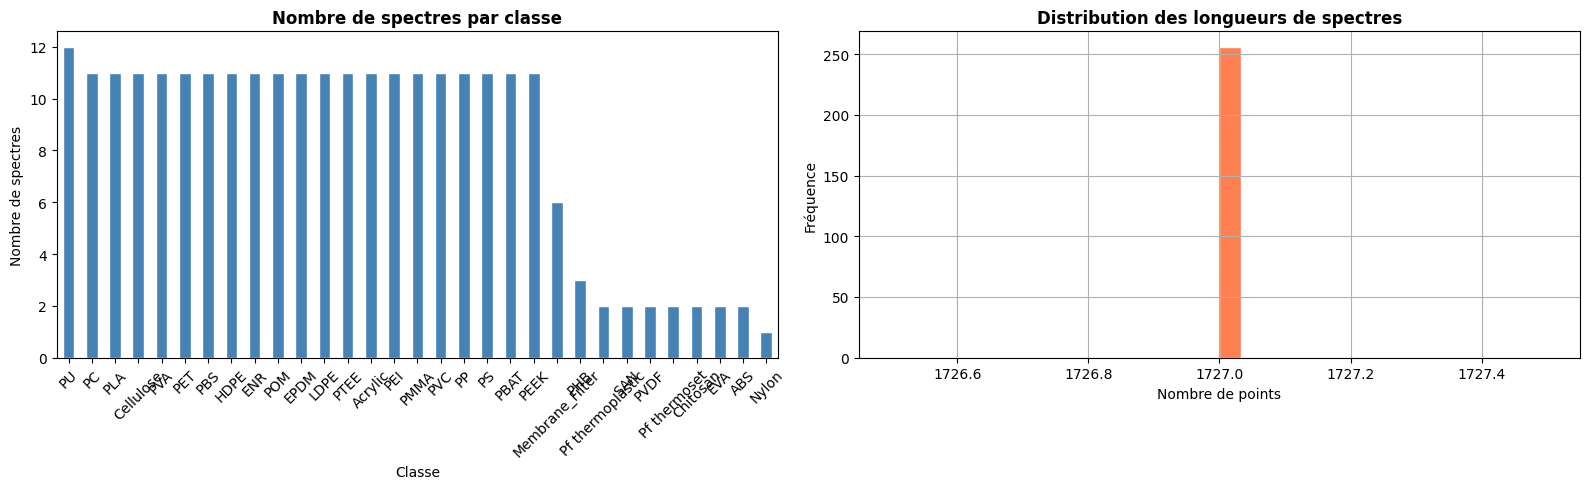

In [ ]:
# ── Statistiques par classe ────────────────────────────────────────────────
print('\n=== Distribution des classes ===')
class_counts = df_all['label'].value_counts()
print(class_counts.to_string())

print(f'\n=== Longueurs de spectres ===')
print(df_all['n_points'].describe())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des classes
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Nombre de spectres par classe', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de spectres')
axes[0].tick_params(axis='x', rotation=45)

# Longueurs des spectres
df_all['n_points'].hist(ax=axes[1], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution des longueurs de spectres', fontweight='bold')
axes[1].set_xlabel('Nombre de points')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

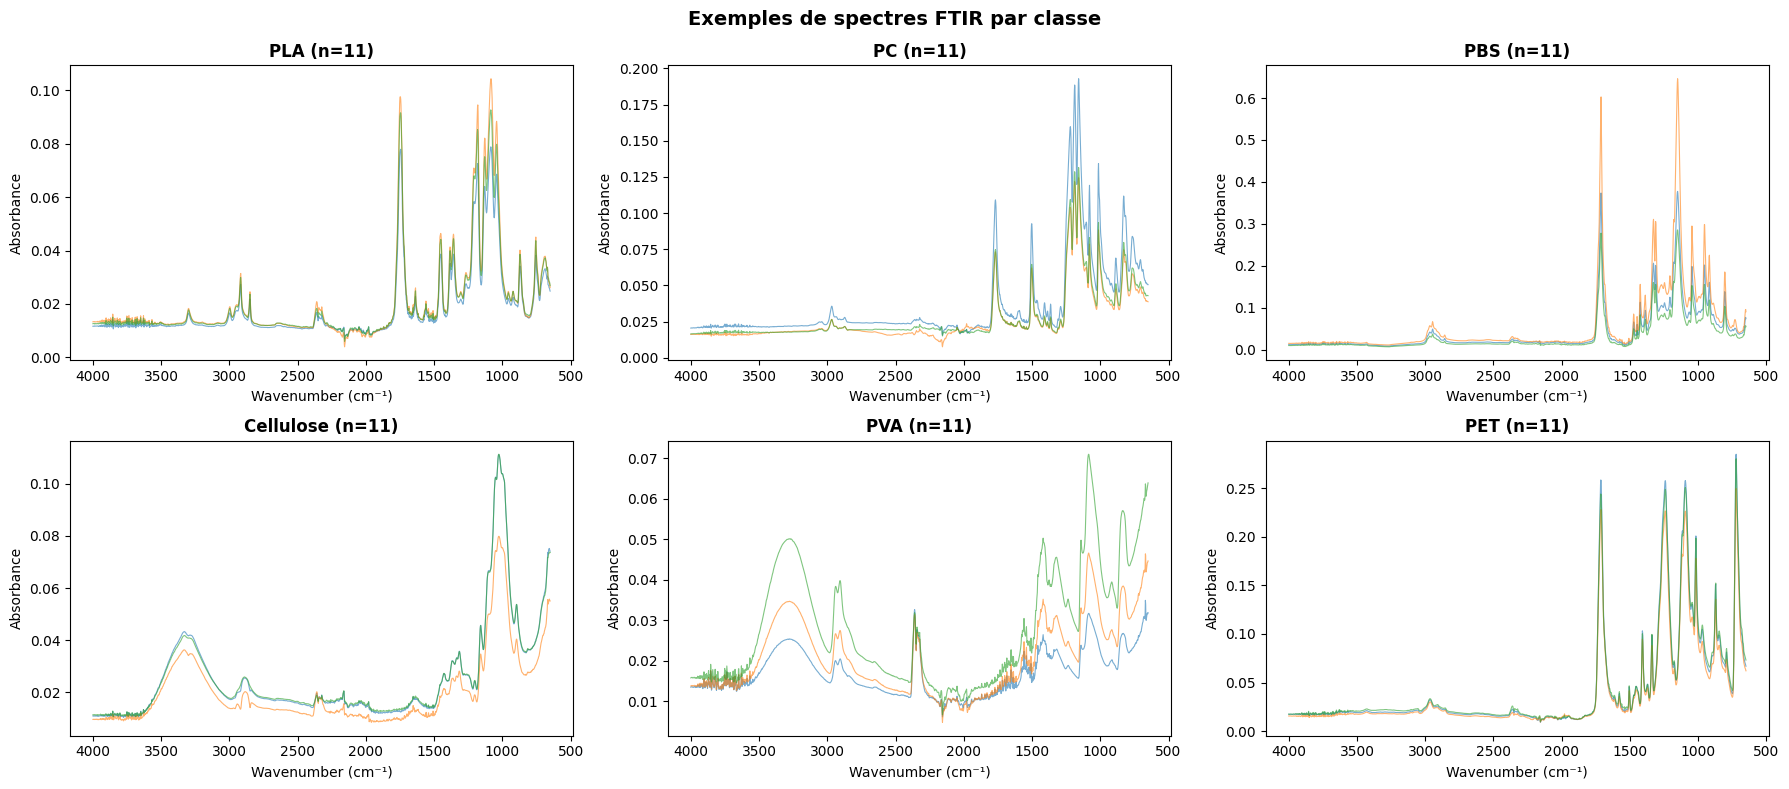

In [ ]:
# ── Visualiser quelques spectres par classe ────────────────────────────────
classes_sample = df_all['label'].unique()[:6]  # 6 premières classes
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(classes_sample):
    subset = df_all[df_all['label'] == cls]
    for _, row in subset.head(3).iterrows():
        axes[i].plot(row['wn'], row['spectrum'], alpha=0.6, linewidth=0.8)
    axes[i].set_title(f'{cls} (n={len(subset)})', fontweight='bold')
    axes[i].set_xlabel('Wavenumber (cm⁻¹)')
    axes[i].set_ylabel('Absorbance')
    axes[i].invert_xaxis()  # convention FTIR : wavenumbers décroissants

plt.suptitle('Exemples de spectres FTIR par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Prétraitement des spectres

Deux problèmes à résoudre avant d'entrer dans PatchTST :
1. **Longueurs différentes** → interpolation sur une grille commune
2. **Normalisation** → instance normalization (comme dans le papier)

In [ ]:
'''
# ── Paramètres de prétraitement ───────────────────────────────────────────
WN_MIN    = 400    # wavenumber minimum à garder (cm⁻¹)
WN_MAX    = 4000   # wavenumber maximum
L         = 1800   # longueur cible après interpolation (résolution ~2 cm⁻¹)

# Grille commune de wavenumbers
WN_GRID = np.linspace(WN_MIN, WN_MAX, L)


def preprocess_spectrum(wn, ab, wn_grid=WN_GRID):
    """
    1. Interpole le spectre sur la grille commune wn_grid
    2. Clip les valeurs aberrantes
    3. Retourne un vecteur numpy de longueur L
    """
    # Interpolation linéaire sur la grille commune
    # np.interp extrapole avec les valeurs bord si hors plage
    ab_interp = np.interp(wn_grid, wn, ab)

    # Remplacer NaN et Inf éventuels
    ab_interp = np.nan_to_num(ab_interp, nan=0.0, posinf=0.0, neginf=0.0)

    return ab_interp.astype(np.float32)


# Appliquer à tout le dataset
print('Interpolation en cours...')
df_all['spectrum_interp'] = df_all.apply(
    lambda row: preprocess_spectrum(row['wn'], row['spectrum']),
    axis=1
)
print(f'✓ Tous les spectres interpolés sur {L} points ({WN_MIN}-{WN_MAX} cm⁻¹)')

# Vérification
shapes = [s.shape for s in df_all['spectrum_interp']]
assert all(s == (L,) for s in shapes), 'Erreur : longueurs incohérentes !'
print(f'✓ Toutes les longueurs = {L}')
'''

In [ ]:
'''
# ── Encodage des labels ────────────────────────────────────────────────────
le = LabelEncoder()
df_all['label_enc'] = le.fit_transform(df_all['label'])

N_CLASSES = len(le.classes_)
print(f'Nombre de classes : {N_CLASSES}')
print('Mapping :')
for i, cls in enumerate(le.classes_):
    count = (df_all['label_enc'] == i).sum()
    print(f'  {i:2d} → {cls:20s}  ({count} spectres)')
'''


## 5. Dataset & DataLoader PyTorch

In [ ]:
'''
class FTIRDataset(Dataset):
    """
    Dataset PyTorch pour les spectres FTIR.

    Applique l'Instance Normalization à la volée :
    chaque spectre est centré-réduit individuellement.
    (comme dans le papier PatchTST)
    """

    def __init__(self, spectra, labels):
        """
        spectra : np.array de shape (N, L)
        labels  : np.array de shape (N,) -- entiers encodés
        """
        self.spectra = torch.tensor(spectra, dtype=torch.float32)
        self.labels  = torch.tensor(labels,  dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.spectra[idx]  # (L,)
        y = self.labels[idx]   # scalaire

        # ── Instance Normalization ──────────────────────────
        # Centrer-réduire chaque spectre individuellement
        mean = x.mean()
        std  = x.std() + 1e-8   # +eps pour éviter division par zéro
        x    = (x - mean) / std

        # PatchTST HuggingFace attend (L, num_channels)
        # Pour 1 canal : (L, 1)
        x = x.unsqueeze(-1)    # (L, 1)

        return x, y


# ── Construction des arrays numpy ─────────────────────────────────────────
X = np.stack(df_all['spectrum_interp'].values)  # (N, L)
y = df_all['label_enc'].values                   # (N,)
print(f'X shape : {X.shape}')   # (N, 1800)
print(f'y shape : {y.shape}')   # (N,)

# ── Split train / val / test  80/10/10 ────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)} spectres')
print(f'Val   : {len(X_val)}   spectres')
print(f'Test  : {len(X_test)}  spectres')
'''

In [ ]:
'''
# ── DataLoaders ───────────────────────────────────────────────────────────
BATCH_SIZE = 32

train_dataset = FTIRDataset(X_train, y_train)
val_dataset   = FTIRDataset(X_val,   y_val)
test_dataset  = FTIRDataset(X_test,  y_test)

# WeightedRandomSampler pour compenser les classes déséquilibrées
class_counts_train = np.bincount(y_train)
weights = 1.0 / class_counts_train[y_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(weights, dtype=torch.float32),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

# Vérification d'un batch
xb, yb = next(iter(train_loader))
print(f'\nShape batch X : {xb.shape}')  # (32, 1800, 1)
print(f'Shape batch y : {yb.shape}')  # (32,)
'''

In [ ]:
# ==========================================
# PARTIE 5 : DATASET & DATALOADER PYTORCH
# ==========================================
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. SPLIT INTELLIGENT (Isolation des filtres)
# ---------------------------------------------------------
# Test terrain : Uniquement les filtres à membrane
df_real_test = df_all[df_all['source'] == 'membrane'].reset_index(drop=True)

# Pool d'entraînement / validation
df_pool = df_all[df_all['source'] != 'membrane']

# --- GESTION DES CLASSES À 1 SEUL SPECTRE ---
class_counts = df_pool['label'].value_counts()
classes_multi = class_counts[class_counts >= 2].index
classes_single = class_counts[class_counts < 2].index

# On sépare le pool en deux groupes
df_pool_multi = df_pool[df_pool['label'].isin(classes_multi)]
df_singletons = df_pool[df_pool['label'].isin(classes_single)]

if len(classes_single) > 0:
    print(f"⚠️ {len(classes_single)} classes n'ont qu'un seul spectre. Elles sont forcées dans le Train.")

# On split uniquement les classes qui ont au moins 2 spectres
df_train_multi, df_val = train_test_split(
    df_pool_multi,
    test_size=0.2,
    random_state=42,
    stratify=df_pool_multi['label']
)

# On fusionne le train avec les classes orphelines
df_train = pd.concat([df_train_multi, df_singletons]).sample(frac=1, random_state=42).reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f"📦 Train : {len(df_train)} spectres")
print(f"📦 Val   : {len(df_val)} spectres")
print(f"🧪 Test (Membranes) : {len(df_real_test)} spectres")

# 2. CLASSE DATASET AVEC INSTANCE NORMALIZATION
# ---------------------------------------------------------
class FTIRDataset(Dataset):
    def __init__(self, df, label_encoder=None):
        self.df = df.reset_index(drop=True)
        self.X = np.stack(self.df['spectrum'].values) # Shape (N, 1727)

        if label_encoder is None:
            self.le = LabelEncoder()
            self.y = self.le.fit_transform(self.df['label'])
        else:
            self.le = label_encoder
            # Sécurité pour ignorer les classes non vues
            self.y = self.le.transform(self.df['label'])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        # INSTANCE NORMALIZATION
        mean = x.mean()
        std  = x.std() + 1e-8
        x    = (x - mean) / std

        # Format [Sequence_Length, Channels]
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        y_tensor = torch.tensor(y, dtype=torch.long)

        return x_tensor, y_tensor

# 3. CRÉATION DES DATALOADERS
# ---------------------------------------------------------
# Important : on fit le LabelEncoder sur TOUT df_pool pour qu'il connaisse toutes les classes
le_global = LabelEncoder()
le_global.fit(df_all['label'])

train_dataset = FTIRDataset(df_train, label_encoder=le_global)
val_dataset   = FTIRDataset(df_val, label_encoder=le_global)
test_dataset  = FTIRDataset(df_real_test, label_encoder=le_global)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Vérification finale
xb, yb = next(iter(train_loader))
print(f"\n✅ Shape batch X : {xb.shape} --> Prêt pour PatchTST")

⚠️ 1 classes n'ont qu'un seul spectre. Elles sont forcées dans le Train.
📦 Train : 200 spectres
📦 Val   : 50 spectres
🧪 Test (Membranes) : 6 spectres

✅ Shape batch X : torch.Size([32, 1727, 1]) --> Prêt pour PatchTST


## 6. Modèle PatchTST

On implémente PatchTST from scratch pour bien contrôler l'architecture  
et comprendre chaque étape sur nos spectres FTIR.

In [ ]:
# ── Hyperparamètres du modèle ─────────────────────────────────────────────
# À adapter selon la taille de ton dataset

CONFIG = {
    # Spectre
    'L'         : 1727,           # longueur du spectre (1800)
    'n_channels': 1,           # 1 seul canal (absorbance)
    'n_classes' : len(le_global.classes_),   # nombre de classes à prédire

    # Patching
    'patch_len' : 16,          # taille d'un patch = 32 cm⁻¹ à résolution 2 cm⁻¹
    'stride'    : 8,           # stride = 16 cm⁻¹ (chevauchement 50%)

    # Transformer
    'D'         : 64,          # dimension latente (petit dataset → 64)
    'n_heads'   : 8,           # têtes d'attention (D doit être divisible par n_heads)
    'n_layers'  : 3,           # couches encodeur
    'd_ff'      : 128,         # dimension feed-forward (= 2*D)
    'dropout'   : 0.1,
    'head_dropout': 0.0,
}

# Vérification D divisible par n_heads
assert CONFIG['D'] % CONFIG['n_heads'] == 0, \
    f"D={CONFIG['D']} doit être divisible par n_heads={CONFIG['n_heads']}"

# Calcul du nombre de patches
P = CONFIG['patch_len']
S = CONFIG['stride']
L = CONFIG['L']
N_patches = (L - P) // S + 2
print(f'Nombre de patches N = {N_patches}')
print(f'Chaque patch couvre {P * (4000 - 650) / L:.1f} cm⁻¹')
print(f'CONFIG : {CONFIG}')

Nombre de patches N = 215
Chaque patch couvre 31.0 cm⁻¹
CONFIG : {'L': 1727, 'n_channels': 1, 'n_classes': 31, 'patch_len': 16, 'stride': 8, 'D': 64, 'n_heads': 8, 'n_layers': 3, 'd_ff': 128, 'dropout': 0.1, 'head_dropout': 0.0}


In [ ]:
class PatchEmbedding(nn.Module):
    """
    Étapes 2 + 3 du pipeline PatchTST :
      - Découpe le spectre en patches (unfold)
      - Projection linéaire Wp  : R^P  → R^D  (contenu)
      - Positional embedding Wpos : position k → R^D
      - Retourne : contenu + position = tokens pour le Transformer

    Entrée  : (B, L, 1)     -- batch de spectres
    Sortie  : (B, N, D)     -- batch de N tokens de dim D
    """

    def __init__(self, L, P, S, D):
        super().__init__()
        self.P = P
        self.S = S
        self.D = D
        self.N = (L - P) // S + 2

        # Wp : projection du contenu de chaque patch
        # nn.Linear(P, D) crée la matrice (D × P) apprise
        self.patch_proj = nn.Linear(P, D)

        # Wpos : une ligne par position de patch, dim D
        # nn.Embedding(N, D) crée la matrice (N × D) apprise
        self.pos_embed  = nn.Embedding(self.N, D)

        self.dropout    = nn.Dropout(0.1)

    def forward(self, x):
        # x : (B, L, 1)
        B = x.shape[0]

        # ── Retirer la dim canal (on est univarié) ──────────
        x = x.squeeze(-1)           # (B, L)

        # ── Padding ─────────────────────────────────────────
        # Répéter la dernière valeur S fois pour compléter
        pad   = x[:, -1:].expand(B, self.S)  # (B, S)
        x_pad = torch.cat([x, pad], dim=1)   # (B, L+S)

        # ── Découpe en patches ───────────────────────────────
        # unfold(dimension, size, step)
        patches = x_pad.unfold(1, self.P, self.S)  # (B, N, P)

        # ── Projection Wp : contenu des patches ─────────────
        # Linear appliqué sur la dernière dim (P → D)
        content = self.patch_proj(patches)          # (B, N, D)

        # ── Positional embedding Wpos ────────────────────────
        positions  = torch.arange(self.N, device=x.device)  # (N,)
        pos_vecs   = self.pos_embed(positions)               # (N, D)
        # broadcast automatique sur le batch : (N, D) → (B, N, D)

        # ── Addition : token = contenu + position ───────────
        tokens = content + pos_vecs   # (B, N, D)

        return self.dropout(tokens)


# Test
embed_test = PatchEmbedding(L=L, P=P, S=S, D=CONFIG['D']).to(device)
x_test = torch.randn(4, L, 1).to(device)
out    = embed_test(x_test)
print(f'PatchEmbedding : {x_test.shape} → {out.shape}')
# Expected : (4, N_patches, D)

PatchEmbedding : torch.Size([4, 1727, 1]) → torch.Size([4, 215, 64])


In [ ]:
class PatchTSTClassifier(nn.Module):
    """
    PatchTST complet pour la classification de spectres FTIR.

    Pipeline :
      1. Instance Norm  (fait dans le Dataset)
      2. PatchEmbedding (patching + projection + pos. encoding)
      3. Transformer Encoder
      4. Pooling global (mean sur les tokens)
      5. Tête de classification (Linear → n_classes)

    Entrée  : (B, L, 1)
    Sortie  : (B, n_classes)  -- logits
    """

    def __init__(self, cfg):
        super().__init__()
        L         = cfg['L']
        P         = cfg['patch_len']
        S         = cfg['stride']
        D         = cfg['D']
        n_heads   = cfg['n_heads']
        n_layers  = cfg['n_layers']
        d_ff      = cfg['d_ff']
        dropout   = cfg['dropout']
        n_classes = cfg['n_classes']

        # ── 1. Patch Embedding ───────────────────────────────
        self.patch_embed = PatchEmbedding(L, P, S, D)

        # ── 2. Transformer Encoder ───────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True,    # important : (B, N, D) pas (N, B, D)
            norm_first=True,     # Pre-Norm comme dans le papier
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # ── 3. Tête de classification ────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(D),
            nn.Dropout(cfg['head_dropout']),
            nn.Linear(D, n_classes),
        )

    def forward(self, x):
        # x : (B, L, 1)

        # ── Patch Embedding ──────────────────────────────────
        tokens = self.patch_embed(x)        # (B, N, D)

        # ── Transformer Encoder ──────────────────────────────
        z = self.transformer(tokens)        # (B, N, D)

        # ── Pooling global : moyenne sur les N tokens ────────
        # Représentation globale du spectre
        z_pooled = z.mean(dim=1)            # (B, D)

        # ── Classification ───────────────────────────────────
        logits = self.head(z_pooled)        # (B, n_classes)

        return logits


# ── Instanciation ─────────────────────────────────────────────────────────
model = PatchTSTClassifier(CONFIG).to(device)

# Compte des paramètres
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres entraînables : {n_params:,}')

# Test forward pass
with torch.no_grad():
    xb_test, _ = next(iter(train_loader))
    out = model(xb_test.to(device))
    print(f'Forward pass : {xb_test.shape} → {out.shape}')
    # Expected : (32, n_classes)

/tmp/ipykernel_1443/1953717617.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Paramètres entraînables : 117,407
Forward pass : torch.Size([32, 1727, 1]) → torch.Size([32, 31])


## 7. Entraînement

In [ ]:
# ── Hyperparamètres d'entraînement ────────────────────────────────────────
N_EPOCHS   = 50
LR         = 1e-3
WEIGHT_DECAY = 1e-4

criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)


def run_epoch(model, loader, criterion, optimizer=None, train=True):
    """Exécute une époque d'entraînement ou de validation."""
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)                          # forward
            loss   = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
                optimizer.step()

            total_loss += loss.item() * len(y)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y).sum().item()
            total      += len(y)

    return total_loss / total, correct / total


# ── Boucle d'entraînement ─────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
CHECKPOINT_PATH = 'best_patchtst_ftir.pt'

print(f'Entraînement sur {N_EPOCHS} époques...')
print(f'{"Époque":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('-' * 60)

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Sauvegarde du meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        flag = ' ← best'
    else:
        flag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:6d} | {train_loss:10.4f} | {train_acc:8.2%} | {val_loss:8.4f} | {val_acc:6.2%}{flag}')

print(f'\n✓ Meilleure Val Acc : {best_val_acc:.2%}')

Entraînement sur 50 époques...
Époque | Train Loss | Train Acc | Val Loss | Val Acc
------------------------------------------------------------
     1 |     3.4626 |    4.50% |   3.3617 |  4.00% ← best
     5 |     3.0813 |   14.00% |   3.0688 | 20.00% ← best
    10 |     2.5503 |   30.00% |   2.6118 | 30.00%
    15 |     2.1875 |   47.50% |   2.4061 | 56.00% ← best
    20 |     1.7088 |   73.50% |   2.0156 | 64.00%
    25 |     1.3909 |   80.00% |   1.7199 | 74.00%
    30 |     1.2102 |   85.50% |   1.5795 | 76.00% ← best
    35 |     1.0935 |   89.00% |   1.5103 | 78.00%
    40 |     1.0379 |   92.00% |   1.4877 | 78.00%
    45 |     1.0118 |   92.00% |   1.4686 | 78.00%
    50 |     1.0227 |   90.00% |   1.4702 | 80.00%

✓ Meilleure Val Acc : 80.00%


In [ ]:
import numpy as np
import torch.nn.functional as F

def classify_spectrum(model, x, le, threshold=0.60):
    """
    Classifie un spectre en microplastique connu OU le signale
    comme spectre inconnu (potentiellement filtre à membrane).

    Retourne un dict avec la prédiction et le niveau de certitude.
    """
    model.eval()
    with torch.no_grad():
        logits = model(x.to(device))
        probs  = F.softmax(logits, dim=1)

        top_conf, top_idx = probs.topk(3, dim=1)
        top_conf = top_conf[0].cpu().numpy()
        top_idx  = top_idx[0].cpu().numpy()

    max_conf = top_conf[0]

    if max_conf < threshold:
        # Entropie de la distribution → mesure d'incertitude
        entropy = -(probs * torch.log(probs + 1e-8)).sum().item()
        return {
            'statut'     : '⚠️  INCONNU — probablement filtre/bruit',
            'prediction' : le_global.classes_[top_idx[0]],
            'confiance'  : f'{max_conf:.1%}',
            'top3'       : [(le_global.classes_[top_idx[i]], f'{top_conf[i]:.1%}')
                            for i in range(3)],
            'entropie'   : f'{entropy:.2f}',
        }
    else:
        return {
            'statut'     : '✅  MICROPLASTIQUE IDENTIFIÉ',
            'prediction' : le_global.classes_[top_idx[0]],
            'confiance'  : f'{max_conf:.1%}',
            'top3'       : [(le_global.classes_[top_idx[i]], f'{top_conf[i]:.1%}')
                            for i in range(3)],
        }


# Test sur tes 6 filtres
for x, _ in test_loader:
    result = classify_spectrum(model, x[:1], le_global)
    print(f"Statut    : {result['statut']}")
    print(f"Top-3     : {result['top3']}")
    print(f"Entropie  : {result.get('entropie', 'N/A')}")
    print()

Statut    : ⚠️  INCONNU — probablement filtre/bruit
Top-3     : [('PET', '22.5%'), ('Cellulose', '12.1%'), ('PEEK', '11.6%')]
Entropie  : 2.70

Statut    : ⚠️  INCONNU — probablement filtre/bruit
Top-3     : [('PBS', '15.8%'), ('PTEE', '13.1%'), ('Acrylic', '10.3%')]
Entropie  : 2.71

Statut    : ⚠️  INCONNU — probablement filtre/bruit
Top-3     : [('PC', '23.9%'), ('PBAT', '19.2%'), ('PTEE', '12.4%')]
Entropie  : 2.57

Statut    : ⚠️  INCONNU — probablement filtre/bruit
Top-3     : [('PET', '18.3%'), ('Cellulose', '10.6%'), ('PEEK', '10.4%')]
Entropie  : 2.82

Statut    : ⚠️  INCONNU — probablement filtre/bruit
Top-3     : [('PVC', '33.7%'), ('PET', '18.0%'), ('ENR', '10.4%')]
Entropie  : 2.42

Statut    : ⚠️  INCONNU — probablement filtre/bruit
Top-3     : [('ENR', '47.1%'), ('PEI', '4.8%'), ('PS', '4.5%')]
Entropie  : 2.32



## 8. Évaluation & Visualisation

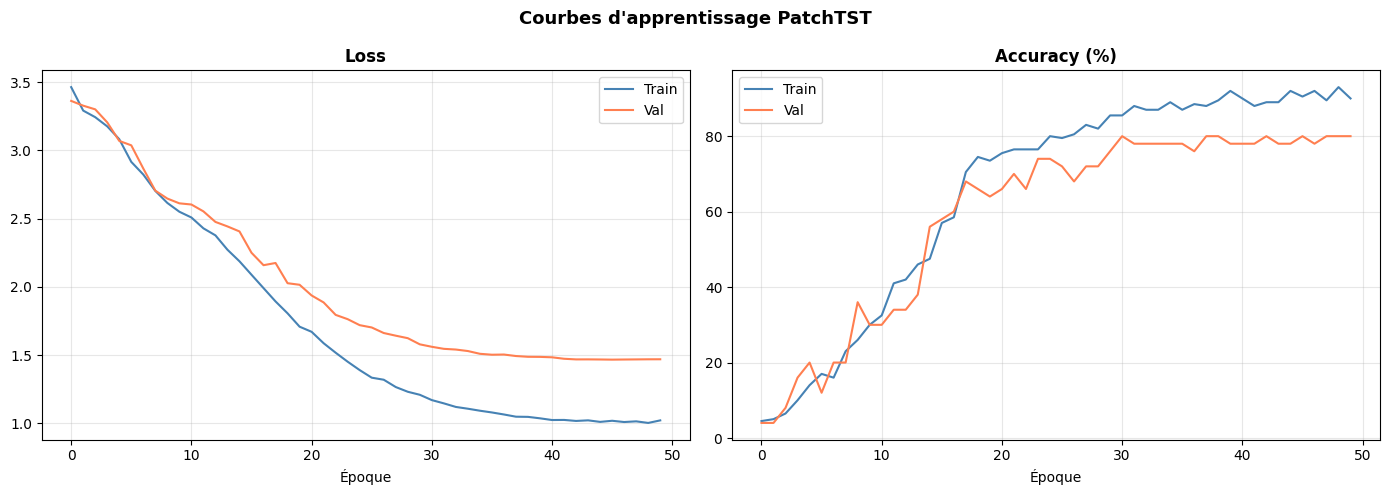

In [ ]:
# ── Courbes d'apprentissage ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='coral')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage PatchTST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Évaluation sur le test set ────────────────────────────────────────────
# Charger le meilleur modèle
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f'\n=== RÉSULTATS SUR LE TEST SET ===')
print(f'Accuracy : {test_acc:.2%}')
print()
print(classification_report(
    all_labels, all_preds,
    labels=range(len(le_global.classes_)),
    target_names=le_global.classes_,
    zero_division=0
))


=== RÉSULTATS SUR LE TEST SET ===
Accuracy : 80.00%

                  precision    recall  f1-score   support

             ABS       0.00      0.00      0.00         1
         Acrylic       1.00      1.00      1.00         2
       Cellulose       0.67      1.00      0.80         2
        Chitosan       0.00      0.00      0.00         1
             ENR       0.50      1.00      0.67         2
            EPDM       1.00      1.00      1.00         2
             EVA       0.00      0.00      0.00         1
            HDPE       1.00      1.00      1.00         2
            LDPE       1.00      1.00      1.00         2
 Membrane_Filter       0.00      0.00      0.00         0
           Nylon       0.00      0.00      0.00         0
            PBAT       1.00      1.00      1.00         2
             PBS       0.33      0.50      0.40         2
              PC       0.67      1.00      0.80         2
            PEEK       1.00      1.00      1.00         2
             PEI 

/tmp/ipykernel_1443/1231051038.py:3: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalisée


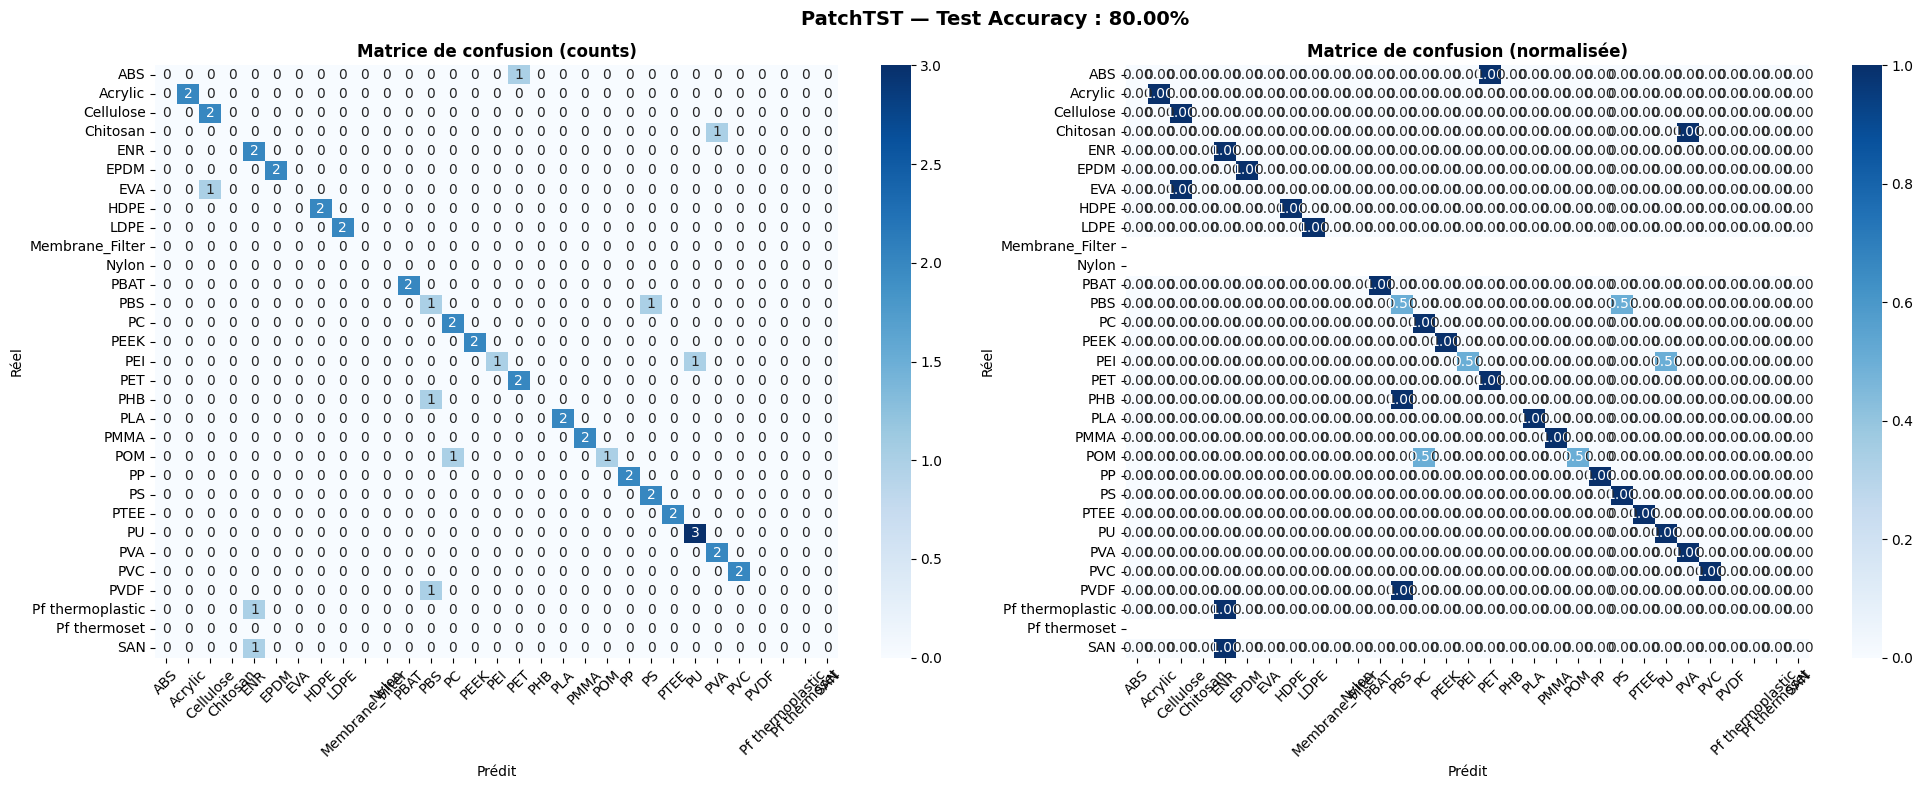

In [ ]:
# ── Matrice de confusion ──────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds,labels=range(len(le_global.classes_)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalisée

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matrice brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_global.classes_, yticklabels=le_global.classes_, ax=axes[0])
axes[0].set_title('Matrice de confusion (counts)', fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Matrice normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_global.classes_, yticklabels=le_global.classes_, ax=axes[1])
axes[1].set_title('Matrice de confusion (normalisée)', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'PatchTST — Test Accuracy : {test_acc:.2%}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Nombre d'erreurs : 10 / 50


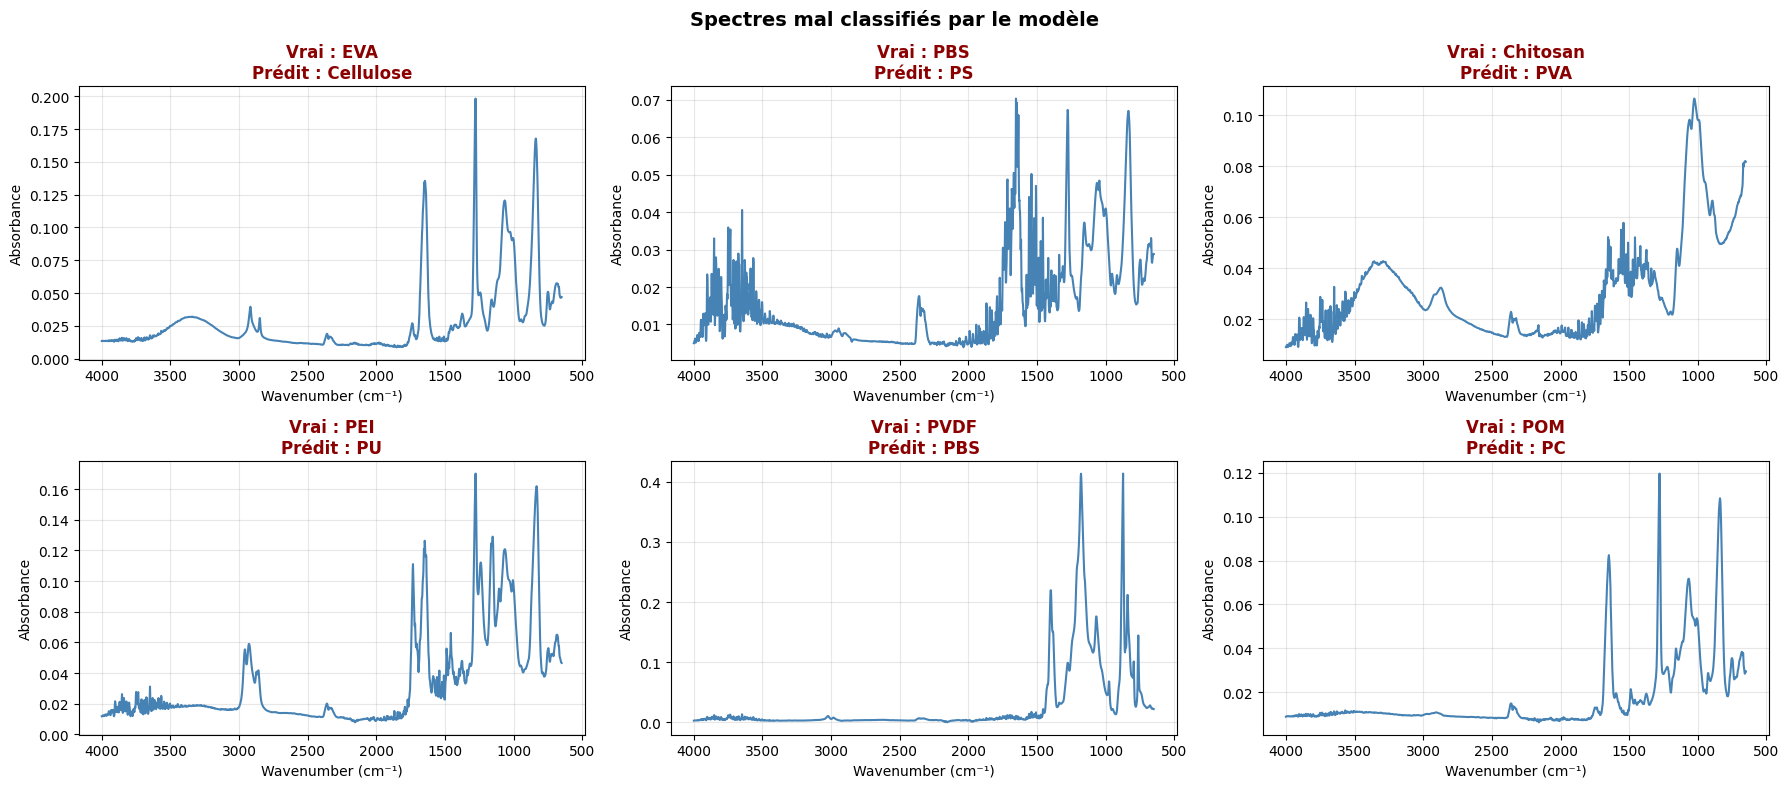

In [ ]:
# ── Visualisation des erreurs : quels spectres sont mal classés ? ─────────
errors_idx = np.where(all_preds != all_labels)[0]
print(f"\nNombre d'erreurs : {len(errors_idx)} / {len(all_labels)}")

if len(errors_idx) > 0:
    n_show = min(6, len(errors_idx))
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()

    for i, err_idx in enumerate(errors_idx[:n_show]):
        true_cls  = le_global.classes_[all_labels[err_idx]]
        pred_cls  = le_global.classes_[all_preds[err_idx]]

        # On récupère le vrai spectre brut dans df_val
        spectrum  = df_val.iloc[err_idx]['spectrum']

        axes[i].plot(TARGET_WAVENUMBERS, spectrum, color='steelblue', linewidth=1.5)
        axes[i].set_title(f'Vrai : {true_cls}\nPrédit : {pred_cls}',
                          fontweight='bold', color='darkred')
        axes[i].set_xlabel('Wavenumber (cm⁻¹)')
        axes[i].set_ylabel('Absorbance')
        axes[i].invert_xaxis() # Crucial pour les spectres FTIR
        axes[i].grid(alpha=0.3)

    # Cacher les cadres vides si tu as moins de 6 erreurs
    for j in range(n_show, 6):
        axes[j].axis('off')

    plt.suptitle('Spectres mal classifiés par le modèle', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("🎉 Aucune erreur ! Le modèle a fait un sans-faute sur ce set.")

Chitosan confondu avec PVA : Ces deux polymères ont des liaisons hydroxyle (O-H) massives qui créent une énorme "montagne" d'absorption vers 3300 cm⁻¹, ainsi que des pics C-O très forts vers 1050 cm⁻¹. L'IA a vu ces pics et a hésité entre les deux.

PEI confondu avec PU : Le Polyetherimide et le Polyuréthane partagent tous les deux des liaisons N-H et des doubles liaisons C=O très marquées.

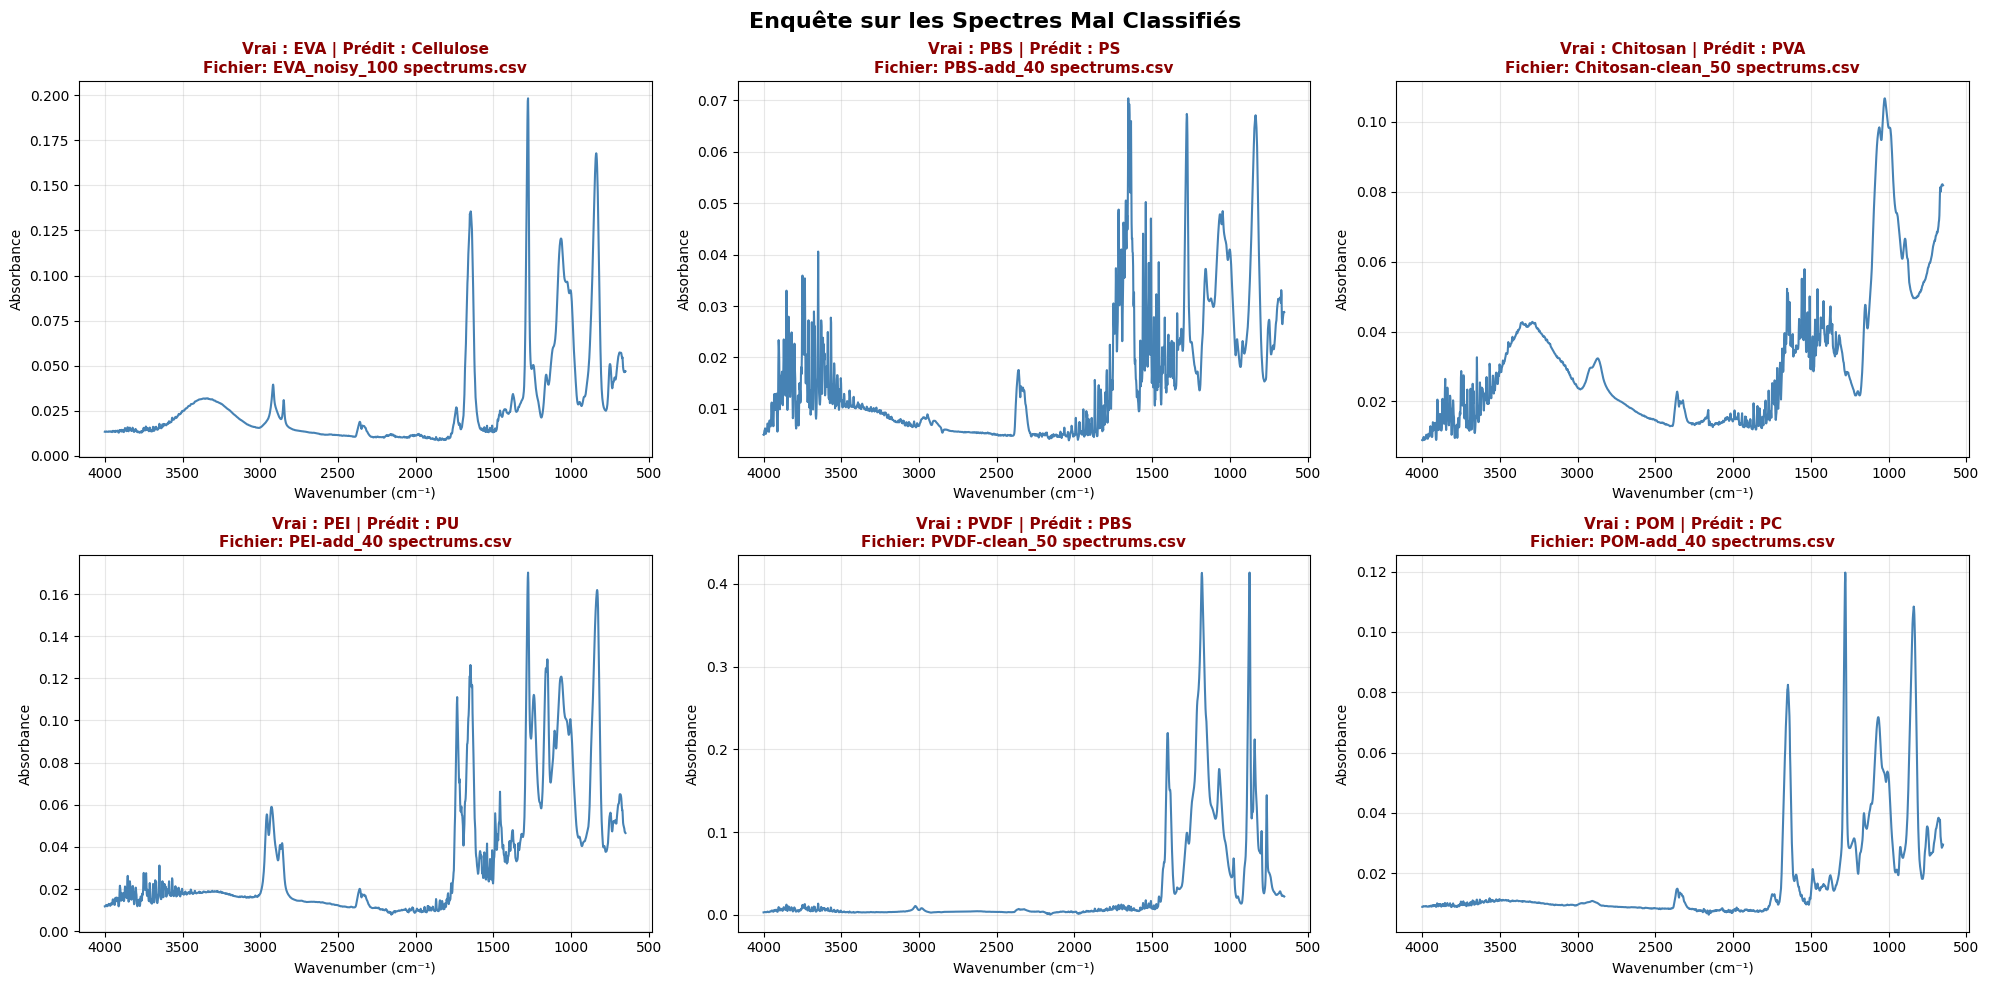

In [ ]:
import os

# ── Visualisation des erreurs : quels spectres sont mal classés ? ─────────
errors_idx = np.where(all_preds != all_labels)[0]

if len(errors_idx) > 0:
    n_show = min(6, len(errors_idx))
    # J'ai agrandi un peu l'image pour que le texte rentre bien
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()

    for i, err_idx in enumerate(errors_idx[:n_show]):
        true_cls  = le_global.classes_[all_labels[err_idx]]
        pred_cls  = le_global.classes_[all_preds[err_idx]]

        # 🔴 NOUVEAUTÉ : On récupère le spectre ET le nom du fichier !
        spectrum  = df_val.iloc[err_idx]['spectrum']
        filepath  = df_val.iloc[err_idx]['filepath']
        filename  = os.path.basename(filepath)

        axes[i].plot(TARGET_WAVENUMBERS, spectrum, color='steelblue', linewidth=1.5)

        # On affiche le vrai nom, la prédiction ET le nom du fichier source
        titre = f'Vrai : {true_cls} | Prédit : {pred_cls}\nFichier: {filename}'
        axes[i].set_title(titre, fontweight='bold', color='darkred', fontsize=11)

        axes[i].set_xlabel('Wavenumber (cm⁻¹)')
        axes[i].set_ylabel('Absorbance')
        axes[i].invert_xaxis()
        axes[i].grid(alpha=0.3)

    for j in range(n_show, 6):
        axes[j].axis('off')

    plt.suptitle('Enquête sur les Spectres Mal Classifiés', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Notes et prochaines étapes

### Ce que tu peux ajuster en priorité

| Paramètre | Valeur actuelle | À tester si |
|-----------|----------------|-------------|
| `patch_len` | 16 (32 cm⁻¹) | Underfitting → essaie 32 ou 64 |
| `D` | 64 | Dataset grand → essaie 128 |
| `n_layers` | 3 | Underfitting → essaie 4-6 |
| `n_heads` | 8 | — doit diviser D |
| `N_EPOCHS` | 50 | Augmente si la loss descend encore |
| `LR` | 1e-3 | Instable → essaie 5e-4 |

### Prochaines étapes
- Inclure ou exclure les spectres **bruités** selon les résultats
- Tester sur les **filtres à membrane** (dossier critique)
- Ajouter les **9 nouvelles classes** de 2025
- Explorer le **pre-training masqué** sur les données non étiquetées
